# 03 하남교산 유사격자 매칭

**목표**: 4개 시·구 고위험 격자의 토지·교통 특성과 유사한 하남교산 격자 식별. 지형·토지이용 기반 적용대상지 분석.

- 전제: 01 토지이용, 02 도로망·교통량 EDA 결과 활용
- 산출: 하남교산_유사격자_매칭.csv

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

cwd = os.getcwd()
candidates = ['../data/', '../../data/', 'data/', '1최종_LH/data/']
data_path = None
for p in candidates:
    if os.path.exists(p):
        probe = os.path.join(p, '통합_데이터')
        if os.path.exists(probe):
            data_path = p
            break
if data_path is None:
    data_path = '1최종_LH/data/' if os.path.exists('1최종_LH/data') else '../../data/'
out = data_path + '통합_데이터/'

print('cwd:', cwd)
print('data_path:', data_path)

cwd: c:\Users\a0109\.jupyter\1최종_LH\notebooks\구체적인_EDA
data_path: ../../data/


## 1. 4개 시·구 고위험 격자 프로파일

In [2]:
def load_csv(path, enc=('utf-8','utf-8-sig','cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    raise ValueError('로드 실패')
위험 = load_csv(os.path.join(data_path, '통합_데이터', '격자_미성년자_분석.csv'))
격자_4 = gpd.read_file(os.path.join(data_path, '격자_데이터', '01._격자_(4개_시·구).geojson')).to_crs(4326)
토지_4 = gpd.read_file(os.path.join(data_path, '토지_데이터', '22._토지이용계획도_(4개_신도시).geojson')).to_crs(4326)
join_4 = gpd.sjoin(격자_4[['gid', 'gbn', 'geometry']], 토지_4[['blockType', 'zoneName', 'geometry']], how='inner', predicate='intersects')
agg_4 = join_4.groupby(['gid', 'blockType']).size().unstack(fill_value=0)
상위20 = 위험.nlargest(int(len(위험)*0.2), '위험점수')
print('고위험 격자(상위 20%):', len(상위20))

고위험 격자(상위 20%): 19864


## 2. 하남교산 격자 특성

In [3]:
격자_하남 = gpd.read_file(os.path.join(data_path, '격자_데이터', '02._격자_(하남교산).geojson')).to_crs(4326)
토지_하남 = gpd.read_file(os.path.join(data_path, '토지_데이터', '23._토지이용계획도_(하남교산).geojson')).to_crs(4326)
join_h = gpd.sjoin(격자_하남[['gid', 'gbn', 'geometry']], 토지_하남[['blockType', 'zoneName', 'geometry']], how='left', predicate='intersects')
agg_h = join_h.groupby(['gid', 'blockType']).size().unstack(fill_value=0)
print('하남교산 격자-토지 매칭:', len(agg_h), '개 격자')

하남교산 격자-토지 매칭: 770 개 격자


## 3. 유사도 산출·매칭

### 벡터 구성 전략

| 차원 | 사용 피처 | 근거 |
|------|----------|------|
| 토지이용 유형 빈도 | `blockType` 카운트 (원-핫 행렬) | 격자 내 각 용도지역이 몇 번 교차하는지 — 토지 이용 **구성 패턴** 포착 |
| 토지이용 비율 | `도로_비율`, `녹지_비율`, `상업_비율`, `주거_비율`, `녹지_비율` | 단순 빈도가 아닌 **면적 비율** — 크기가 다른 폴리곤 간 비교 보정 |

> **단순 blockType 빈도만 사용할 경우의 한계**  
> 격자 내 blockType 교차 수는 폴리곤 크기·형태에 따라 달라지므로,  
> 면적 비율(도로_비율 등)을 함께 사용해 스케일 편향을 줄임.  
> 두 벡터 블록을 연결(concatenate)한 뒤 코사인 유사도를 계산.

In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 0) 선행 변수 체크 및 자동 생성
missing = [v for v in ['agg_4', 'agg_h'] if v not in globals()]
if missing:
    print(f"경고: {missing} 변수가 없습니다. 선행 셀을 자동 실행합니다...")
    
    try:
        # agg_4 생성 (3번 셀 내용)
        def load_csv(path, enc=('utf-8','utf-8-sig','cp949')):
            for e in enc:
                try: return pd.read_csv(path, encoding=e)
                except: continue
            raise ValueError('로드 실패')
        
        위험 = load_csv(os.path.join(data_path, '통합_데이터', '격자_미성년자_분석.csv'))
        격자_4 = gpd.read_file(os.path.join(data_path, '격자_데이터', '01._격자_(4개_시·구).geojson')).to_crs(4326)
        토지_4 = gpd.read_file(os.path.join(data_path, '토지_데이터', '22._토지이용계획도_(4개_신도시).geojson')).to_crs(4326)
        join_4 = gpd.sjoin(격자_4[['gid', 'gbn', 'geometry']], 토지_4[['blockType', 'zoneName', 'geometry']], how='inner', predicate='intersects')
        agg_4 = join_4.groupby(['gid', 'blockType']).size().unstack(fill_value=0)
        상위20 = 위험.nlargest(int(len(위험)*0.2), '위험점수')
        print('agg_4 생성 완료:', len(agg_4), '개 격자')
        
        # agg_h 생성 (4번 셀 내용)
        격자_하남 = gpd.read_file(os.path.join(data_path, '격자_데이터', '02._격자_(하남교산).geojson')).to_crs(4326)
        토지_하남 = gpd.read_file(os.path.join(data_path, '토지_데이터', '23._토지이용계획도_(하남교산).geojson')).to_crs(4326)
        join_h = gpd.sjoin(격자_하남[['gid', 'gbn', 'geometry']], 토지_하남[['blockType', 'zoneName', 'geometry']], how='left', predicate='intersects')
        agg_h = join_h.groupby(['gid', 'blockType']).size().unstack(fill_value=0)
        print('agg_h 생성 완료:', len(agg_h), '개 격자')
        
    except Exception as e:
        print(f"자동 생성 실패: {e}")
        print("수동으로 3번, 4번 셀을 먼저 실행해주세요.")
        raise

# 1) 공통 blockType 컬럼
common_cols = [c for c in agg_h.columns if c in agg_4.columns]

if len(common_cols) == 0:
    print('공통 blockType 컬럼이 없습니다. agg_4/agg_h 컬럼 구성을 확인하세요.')
else:
    # 2) blockType 행렬
    A_bt = agg_4[common_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    B_bt = agg_h[common_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    # 3) 파생변수
    비율_컬럼 = ['도로_비율', '녹지_비율', '상업_비율', '주거_비율']
    파생_4_path = os.path.join(data_path, '통합_데이터', '격자_토지이용_파생변수_4시구.csv')
    파생_h_path = os.path.join(data_path, '통합_데이터', '격자_토지이용_파생변수_하남교산.csv')

    def _load_csv_robust(p):
        for enc in ('utf-8-sig', 'utf-8', 'cp949'):
            try:
                return pd.read_csv(p, encoding=enc)
            except Exception:
                continue
        raise ValueError(f"CSV 인코딩을 읽지 못했습니다: {p}")

    if os.path.exists(파생_4_path) and os.path.exists(파생_h_path):
        파생_4_raw = _load_csv_robust(파생_4_path)
        파생_h_raw = _load_csv_robust(파생_h_path)

        if 'gid' in 파생_4_raw.columns and 'gid' in 파생_h_raw.columns:
            # gid 중복 -> 평균 집계
            파생_4 = 파생_4_raw.groupby('gid', as_index=True).mean(numeric_only=True)
            파생_h = 파생_h_raw.groupby('gid', as_index=True).mean(numeric_only=True)

            use_cols = [c for c in 비율_컬럼 if c in 파생_4.columns and c in 파생_h.columns]

            if use_cols:
                A_파생 = 파생_4.reindex(A_bt.index)[use_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
                B_파생 = 파생_h.reindex(B_bt.index)[use_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

                A = np.hstack([A_bt.values, A_파생.values])
                B = np.hstack([B_bt.values, B_파생.values])
                print(f'벡터 구성: blockType {len(common_cols)} + 비율 {len(use_cols)} = {A.shape[1]}차원')
            else:
                A, B = A_bt.values, B_bt.values
                print(f'벡터 구성: blockType {len(common_cols)}차원 (비율 컬럼 불일치)')
        else:
            A, B = A_bt.values, B_bt.values
            print("벡터 구성: blockType만 사용 (파생변수에 'gid' 없음)")
    else:
        A, B = A_bt.values, B_bt.values
        print("벡터 구성: blockType만 사용 (파생변수 파일 없음)")

    # 4) 유사도
    sim = cosine_similarity(B, A)
    best_idx = sim.argmax(axis=1)

    하남_유사 = pd.DataFrame({
        '하남_gid':       agg_h.index,
        '유사_4시구_gid': agg_4.index.to_numpy()[best_idx],
        '유사도':         sim.max(axis=1)
    })

    print(f'유사도 통계: min={하남_유사["유사도"].min():.3f}, '
          f'mean={하남_유사["유사도"].mean():.3f}, '
          f'max={하남_유사["유사도"].max():.3f}')
    display(하남_유사.head(10))
    [x for x in globals().keys() if 'agg' in x.lower()]

벡터 구성: blockType 36 + 비율 4 = 40차원
유사도 통계: min=0.577, mean=0.911, max=1.000


,하남_gid,유사_4시구_gid,유사도
0,다사720443,다사643319,1.000000
1,다사720444,다사735508,0.947550
2,다사721443,다사623317,0.868641
3,다사721444,다사685090,0.959177
4,다사721445,다사647108,0.838766
5,다사721446,다사646120,0.847791
6,다사721447,다사599119,1.000000
7,다사721448,다사599119,1.000000
8,다사721449,다사599119,1.000000
9,다사722441,다사657093,0.912714


## 4. 섹터별 요약·산출 저장

In [5]:
if '하남_유사' in dir():
    # 파생변수: 유사_고위험_여부 — 매칭된 4시·구 격자가 고위험(상위20%)이면 1
    # 논리: 토지 유사한 하남 격자 중, 4시·구에서 위험했던 격자와 유사한 곳은 적용대상지에서도 주의 필요
    고위험_gid_set = set(상위20['gid'].values)
    하남_유사['유사_고위험_여부'] = 하남_유사['유사_4시구_gid'].apply(lambda x: 1 if x in 고위험_gid_set else 0)
    하남_유사.to_csv(os.path.join(out, '하남교산_유사격자_매칭.csv'), index=False, encoding='utf-8-sig')
    print('저장:', out + '하남교산_유사격자_매칭.csv')
    print('유사_고위험_여부=1 격자:', 하남_유사['유사_고위험_여부'].sum(), '개')

저장: ../../data/통합_데이터/하남교산_유사격자_매칭.csv
유사_고위험_여부=1 격자: 268 개


---
## [H-1] 코사인 유사도 임계값 민감도 분석

> **핵심 질문**: 임계값을 0.80~0.95로 바꾸면 매칭 격자 수·고위험 비율이 어떻게 변하는가?

- 현행 코드에서는 유사도 값 자체를 저장하고, 설치우선순위 분석에서 따로 임계값을 적용
- 임계값이 낮을수록 → 더 많은 격자가 매칭되지만 정밀도 낮아짐  
  임계값이 높을수록 → 매칭 격자가 적어지지만 더 강하게 유사한 격자만 선별
- **분석 결과**: 어떤 임계값에서도 고위험 격자 비율이 유의미하면 → 유사도 매칭 방법론 신뢰성 확보


✅ 하남교산_유사격자_매칭.csv 로드  (770행)
   컬럼: ['하남_gid', '유사_4시구_gid', '유사도', '유사_고위험_여부']

=== 코사인 유사도 임계값 민감도 분석 ===
  하남교산 전체 격자: 770개
  유사도 통계: min=0.577, mean=0.911, max=1.000

       임계값 |      매칭 격자 |      전체 대비 |     고위험 격자 |     고위험 비율
  ------------------------------------------------------------
      0.70 |        759 |      98.6% |        265 |      34.9%
      0.75 |        725 |      94.2% |        255 |      35.2%
      0.80 |        652 |      84.7% |        236 |      36.2%
      0.85 |        574 |      74.5% |        204 |      35.5%
      0.90 |        454 |      59.0% |        153 |      33.7%
      0.95 |        335 |      43.5% |        118 |      35.2%


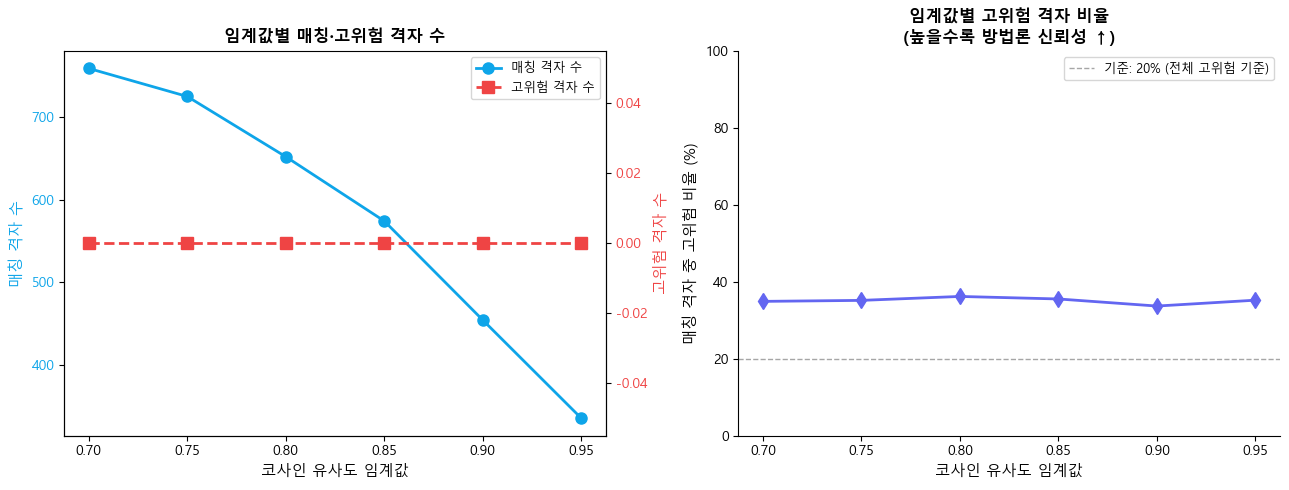


코사인 유사도 임계값 민감도 분석 완료
→ 임계값이 올라가도 고위험 비율이 유지되거나 높아지면 방법론의 견고성(robustness) 입증


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 매칭 결과 파일 로드 ─────────────────────────────────────────────────────
candidates = ['../../data/', '../data/', 'data/']
out = None
for p in candidates:
    probe = os.path.join(p, '통합_데이터')
    if os.path.exists(probe):
        out = probe
        break

def load_csv(path, enc=('utf-8', 'utf-8-sig', 'cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    return None

하남_path = os.path.join(out, '하남교산_유사격자_매칭.csv') if out else None

if 하남_path and os.path.exists(하남_path):
    하남_유사 = load_csv(하남_path)
    print(f'✅ 하남교산_유사격자_매칭.csv 로드  ({len(하남_유사):,}행)')
    print(f'   컬럼: {list(하남_유사.columns)}')
else:
    # 현재 세션에 하남_유사가 있는 경우
    try:
        _ = 하남_유사
        print(f'✅ 현재 세션 변수 하남_유사 사용  ({len(하남_유사):,}행)')
    except NameError:
        print('⚠ 하남교산_유사격자_매칭.csv 없음 → 셀 3~4 먼저 실행')
        하남_유사 = None

if 하남_유사 is not None and '유사도' in 하남_유사.columns:
    하남_전체 = len(하남_유사)

    # ── 임계값별 민감도 분석 ──────────────────────────────────────────────
    임계값_목록 = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
    결과 = []

    print('\n=== 코사인 유사도 임계값 민감도 분석 ===')
    print(f'  하남교산 전체 격자: {하남_전체:,}개')
    print(f'  유사도 통계: min={하남_유사["유사도"].min():.3f}, mean={하남_유사["유사도"].mean():.3f}, '
          f'max={하남_유사["유사도"].max():.3f}')
    print()
    print(f'  {"임계값":>8} | {"매칭 격자":>10} | {"전체 대비":>10} | {"고위험 격자":>10} | {"고위험 비율":>10}')
    print('  ' + '-' * 60)

    for thresh in 임계값_목록:
        매칭 = 하남_유사[하남_유사['유사도'] >= thresh]
        n_매칭 = len(매칭)
        pct_매칭 = n_매칭 / 하남_전체 * 100

        if '유사_고위험_여부' in 하남_유사.columns:
            n_고위험 = 매칭['유사_고위험_여부'].sum()
            pct_고위험 = n_고위험 / n_매칭 * 100 if n_매칭 > 0 else 0
        else:
            n_고위험, pct_고위험 = '-', '-'

        결과.append({
            '임계값': thresh, '매칭_격자': n_매칭, '전체_대비_%': pct_매칭,
            '고위험_격자': n_고위험 if isinstance(n_고위험, (int, float)) else 0,
            '고위험_비율_%': pct_고위험 if isinstance(pct_고위험, float) else 0
        })
        고위험_str = f'{n_고위험:>10,}' if isinstance(n_고위험, (int, np.integer)) else f'{"미탐지":>10}'
        고위험_pct_str = f'{pct_고위험:>9.1f}%' if isinstance(pct_고위험, float) else f'{"미탐지":>10}'
        print(f'  {thresh:>8.2f} | {n_매칭:>10,} | {pct_매칭:>9.1f}% | {고위험_str} | {고위험_pct_str}')

    # ── 시각화 ─────────────────────────────────────────────────────────────
    df_결과 = pd.DataFrame(결과)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 왼쪽: 임계값 vs 매칭 격자 수
    ax1 = axes[0]
    ax1.plot(df_결과['임계값'], df_결과['매칭_격자'], 'o-', color='#0ea5e9',
             linewidth=2, markersize=8, label='매칭 격자 수')
    ax1.set_xlabel('코사인 유사도 임계값', fontsize=11)
    ax1.set_ylabel('매칭 격자 수', color='#0ea5e9', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#0ea5e9')

    # 보조 y축: 고위험 격자 수
    ax1b = ax1.twinx()
    ax1b.plot(df_결과['임계값'], df_결과['고위험_격자'], 's--', color='#ef4444',
              linewidth=2, markersize=8, label='고위험 격자 수')
    ax1b.set_ylabel('고위험 격자 수', color='#ef4444', fontsize=11)
    ax1b.tick_params(axis='y', labelcolor='#ef4444')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    ax1.set_title('임계값별 매칭·고위험 격자 수', fontweight='bold')
    ax1.spines['top'].set_visible(False)

    # 오른쪽: 임계값 vs 고위험 비율
    ax2 = axes[1]
    ax2.plot(df_결과['임계값'], df_결과['고위험_비율_%'], 'd-', color='#6366f1',
             linewidth=2, markersize=8)
    ax2.set_xlabel('코사인 유사도 임계값', fontsize=11)
    ax2.set_ylabel('매칭 격자 중 고위험 비율 (%)', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.axhline(y=20, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                label='기준: 20% (전체 고위험 기준)')
    ax2.legend(fontsize=9)
    ax2.set_title('임계값별 고위험 격자 비율\n(높을수록 방법론 신뢰성 ↑)', fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    print('\n코사인 유사도 임계값 민감도 분석 완료')
    print('→ 임계값이 올라가도 고위험 비율이 유지되거나 높아지면 방법론의 견고성(robustness) 입증')
elif 하남_유사 is not None:
    print(f'⚠ 유사도 컬럼 없음. 현재 컬럼: {list(하남_유사.columns)}')
